# Grammar Scoring from Spoken Audio
*SHL Research Engineer challenge: my solution and write-up*

**The task:** take an audio file of someone speaking English (mostly 45–60 seconds) and output a continuous grammar score from 0 to 5.
There are 769 training clips and 216 test clips. The competition evaluates with **Pearson correlation** and **RMSE**, so I report both
for every model. The Kaggle leaderboard itself ranks by RMSE (lower is better: the top scores are the lowest numbers), so I use RMSE
to make decisions, and check that Pearson improves too. In practice the two agreed at every step.

Here's the rubric the scores are based on (shortened). The data also has some clips scored **0**, which I discuss in section 1.

| Score | What it means |
|:-:|:--|
| 1 | Struggles with sentence structure; limited control of simple grammar |
| 2 | Uses simple structures but makes consistent basic mistakes; leaves sentences incomplete |
| 3 | Decent grasp of sentence structure *or* grammar, but errors in the other |
| 4 | Strong control; occasional minor errors that don't cause misunderstanding |
| 5 | High accuracy, handles complex grammar, corrects themselves |

## Pipeline architecture
Each clip goes through two models, a text model and an audio model, which are then combined
(the drawing code is in `pipeline_diagram.py`):

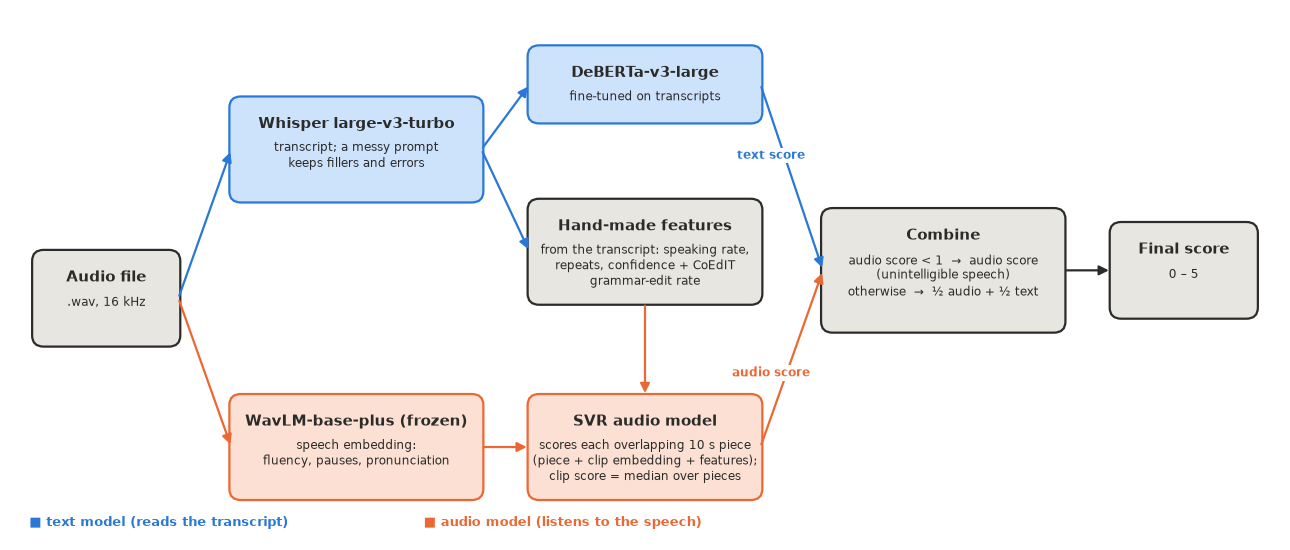

In [1]:
from pipeline_diagram import draw
draw();   # boxes and arrows of the pipeline - see the table in section 3 for the hand-made features

The combining rule, in words: if the audio model scores a clip **below 1** (under the rubric's minimum), the speech is
unintelligible and that score is used on its own; otherwise the final score is the **average of the audio and text scores**
(why, in section 6).

`predict.py` runs this whole pipeline on any `.wav` file (demo in section 8).

**How this notebook runs:** my laptop (an M1 MacBook Air) overheated running Whisper, so I moved the heavy steps (Whisper, grammar correction,
WavLM, DeBERTa) to Kaggle's free GPU. That code is in the `kaggle_*/` folders. This notebook loads their saved outputs from `kaggle_out/`,
`transcripts/` and `gec.json`. Those outputs are **not in the GitHub repo**, because the competition rules don't allow redistributing the data
or anything derived from it. The README explains how to re-create them. The saved outputs in this notebook show every result.

In [2]:
# --- Setup -------------------------------------------------------------------------------------------
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
warnings.filterwarnings("ignore")

import features as F   # my feature code: transcript loading, hand-made features, grammar-correction features, embeddings
import train as T      # my model definitions (Ridge baseline, SVR audio model) and RMSE helper, shared with train.py and predict.py

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
CV = KFold(5, shuffle=True, random_state=42)   # 5-fold CV over all 769 clips, used for every model evaluated in this notebook
rmse, pear = T.rmse, lambda y, p: pearsonr(y, p)[0]
BLUE, ORANGE, AQUA, INK = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"   # colour-blind-safe palette
AUDIO_NPZ = 'kaggle_out/audio/audio_emb.npz'
TEXT_OOF, TEXT_TEST = 'kaggle_out/deberta_large/oof_deberta_large.csv', 'kaggle_out/deberta_large/test_deberta_large.csv'

## 1. Looking at the data first

train 769 clips (37 scored 0), test 216 clips


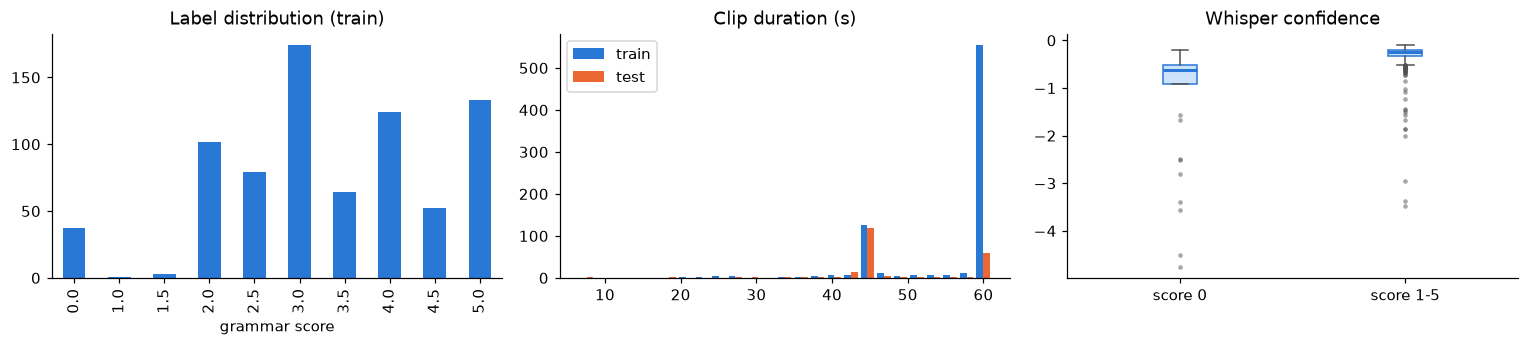

In [3]:
# F.load() joins each CSV row with its Whisper transcript and ASR metadata (duration, loudness, confidence)
train, test = F.load("train"), F.load("test")
y = train.label.to_numpy()
is0 = y == 0                                   # the clips scored 0 (outside the 1-5 rubric)
print(f"train {len(train)} clips ({is0.sum()} scored 0), test {len(test)} clips")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
train.label.value_counts().sort_index().plot.bar(ax=ax[0], color=BLUE)
ax[0].set_title("Label distribution (train)"); ax[0].set_xlabel("grammar score")
ax[1].hist([train.duration, test.duration], bins=25, label=["train", "test"], color=[BLUE, ORANGE])
ax[1].legend(); ax[1].set_title("Clip duration (s)")
# Whisper's average log-probability = how confident it was about the words it heard
train.assign(group=np.where(is0, "score 0", "score 1-5")).boxplot(
    "avg_logprob", by="group", ax=ax[2], grid=False, patch_artist=True, boxprops=dict(facecolor="#cde2fb", color=BLUE),
    medianprops=dict(color=BLUE, lw=2), whiskerprops=dict(color=INK), capprops=dict(color=INK),
    flierprops=dict(marker="o", markersize=3, markerfacecolor=INK, markeredgecolor="none", alpha=0.5))
ax[2].set_title("Whisper confidence"); ax[2].set_xlabel(""); fig.suptitle(""); plt.tight_layout(); plt.show()

**What I noticed:**
- Most scores are between 3 and 5. There are only 4 clips scored 1–1.5, so I expect the model to struggle most at the low end.
- The competition describes the clips as 45–60 seconds, and most are, but not all: 7% of training clips and 12% of test clips
  are shorter (the shortest test clip is 6.5 s), and a few run just over 60 s (middle plot). Every step works on any length,
  so I didn't cut or pad anything; `predict.py` only needs at least 1 second of audio.
- **37 clips are scored 0**, which isn't on the 1–5 rubric. My first guess was that they were silent, but they have normal
  amounts of speech. What's different is that Whisper is much less confident on them (right plot), and sometimes outputs random
  characters from other languages (examples below). So I think these are **unintelligible or off-topic recordings**.

At first I dropped these clips from training, because my early text-only model couldn't tell them apart from real speakers
and they were pulling all predictions down. But the task asks for a model that outputs **0 to 5**, so a model that can never output 0
doesn't fully solve it. Once I added audio features, it turned out the model *can* recognise these clips (section 6). So I kept them.

In [4]:
# A few transcripts of score-0 clips: Whisper struggles to make sense of the speech
for t in train.text[is0].head(3): print(" *", t[:60] + "...")   # short quotes only: the data may not be redistributed

 * If we use Ris 우와 cure марay Troy of poetry, it was about 10p...
 * The best, the best day in our life is the best day together....
 * To my point of view, send me an automatically. I love, I can...


## 2. Turning speech into text with Whisper
Grammar is about which words people use and in what order, so my first step was to transcribe the audio.
I used **Whisper large-v3-turbo** (code in `kaggle_asr/`, and the same settings locally in `transcribe.py`).

**A problem I ran into:** Whisper is trained to produce clean, readable text. It drops "uh" and "um", skips false starts, and can
even smooth over grammar mistakes. That's great for subtitles but bad for this task, because those mistakes are exactly what I want to measure.

**What I did about it:** Whisper continues in the style of its starting prompt. So I gave it a prompt written in messy, broken English
(*"Umm, so I was, uh, I go to the market and, like, I buyed some..."*), and it transcribed more faithfully.
I tested this on 10 low-scored clips: **with the prompt it kept 9 fillers, without it kept 0.** False starts like
*"we have, we, we want 11 students"* only survived with the prompt. Grammar mistakes like *"we are enjoy a lot"* showed up in both.

It's not perfect: Whisper still cleans up some speech, and I can't measure exactly how much without human-written transcripts.
Here are a few transcripts at different score levels. The difference in grammar is easy to see:

In [5]:
# Two random transcripts per score band (fixed seed so the output is reproducible)
for lo, hi in [(1, 2), (3, 3), (5, 5)]:
    print(f"--- score {lo}-{hi}")
    for t in train[train.label.between(lo, hi)].sample(2, random_state=1).text: print("  *", t[:70] + "...")   # short quotes only

--- score 1-2
  * My travel journey experience destination is in Tagaytay. Some of it is...
  * Well, in the airport there is a lot of people that is going to travel ...
--- score 3-3
  * Well, when I stay at a resort, what I like to do is always be on the p...
  * My favorite hobby is knitting. I enjoy about that hobby because... I e...
--- score 5-5
  * My favorite hobby is playing video games. What I enjoy the most about ...
  * My goal in life is to leave the world a better place than I found it. ...


## 3. Simple features I can explain
Before trying bigger models, I wanted some features where I could say *why* they should relate to grammar (code in `features.py`):

| feature | why I thought it would help |
|---|---|
| `words_per_sec`, `n_words` | fluent speakers say more in the same amount of time |
| `mean_sentence_len` | weaker speakers tend to use short or broken-off sentences |
| `filler_rate`, `repeat_rate` | hesitation and false starts ("I I", "the the") |
| `type_token_ratio`, `mean_word_len` | how varied the vocabulary is |
| `avg_logprob`, `no_speech_prob`, `non_ascii_rate`, `rms` | how clearly Whisper could understand the speaker; loudness |
| **`gec_edit_rate`, `gec_changed_frac`** | **a direct grammar signal:** I ran every sentence through a grammar-correction model (Grammarly's CoEdIT, `kaggle_gec/`) and measured what fraction of words it had to change. I ignore changes to capitalisation and punctuation, so only real word fixes count. |

Here's an example of what the grammar-correction model does, and how each feature correlates with the score:

ORIG: A crowded market often means more opportunity, not less opportunity.
CORR: A crowded market often means more opportunity, not less opportunity. 

ORIG: First, if a market crowded, it means that there is plenty of demand.
CORR: First, if a market is crowded, it means that there is plenty of demand 



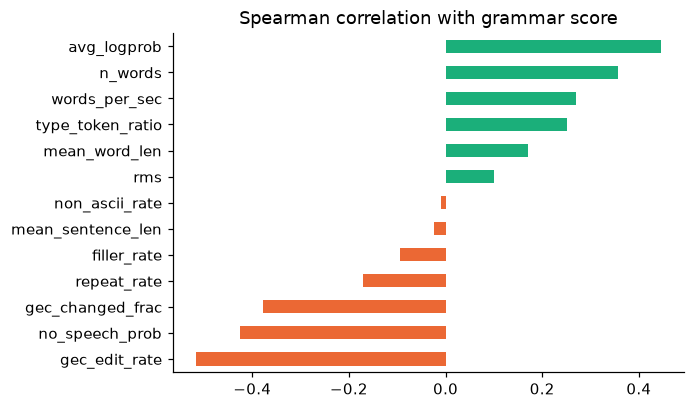

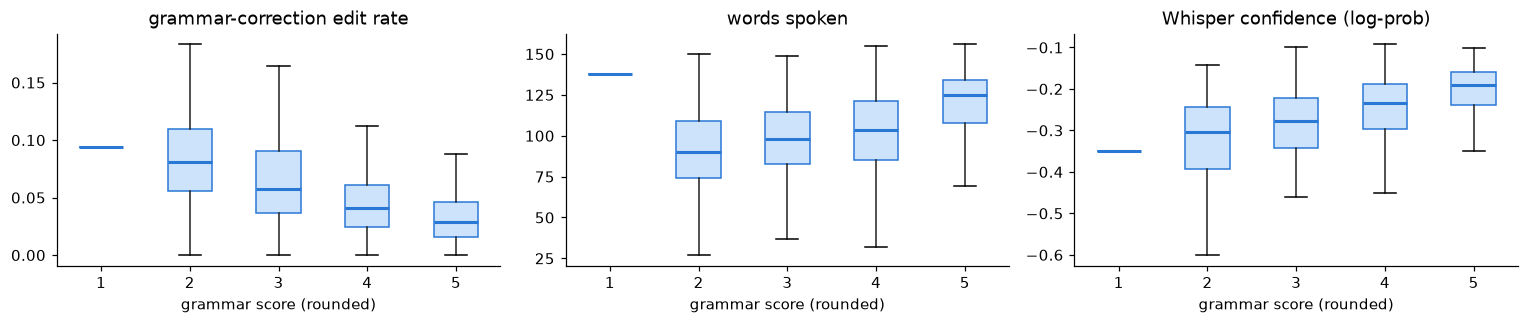

In [6]:
# gec.json holds (original sentence, corrected sentence) pairs produced on Kaggle by CoEdIT
gec = json.loads(Path("gec.json").read_text())
example = "train_" + train[train.label == 1.5].filename.iloc[0][:-4]
for orig, corr in gec[example][:2]:
    print("ORIG:", orig[:70]); print("CORR:", corr[:70], "\n")

H = F.handcrafted(train, "train")              # one row of hand-made features per clip
# Spearman (rank) correlation with the score, on the 1-5 clips so the score-0 clips don't dominate
corr = H[~is0].apply(lambda c: c.corr(train.label[~is0], method="spearman")).sort_values()
corr.plot.barh(figsize=(6, 4), color=np.where(corr > 0, AQUA, ORANGE), title="Spearman correlation with grammar score")
plt.show()

# How the three strongest features change across score levels (1-5 clips)
fig, ax = plt.subplots(1, 3, figsize=(14, 3.2))
for a, col, title in zip(ax, ["gec_edit_rate", "n_words", "avg_logprob"],
                         ["grammar-correction edit rate", "words spoken", "Whisper confidence (log-prob)"]):
    d = H[~is0].assign(score=train.label[~is0].round().astype(int))
    d.boxplot(col, by="score", ax=a, grid=False, showfliers=False, patch_artist=True,
              boxprops=dict(facecolor="#cde2fb", color=BLUE), medianprops=dict(color=BLUE, lw=2))
    a.set_title(title); a.set_xlabel("grammar score (rounded)")
fig.suptitle(""); plt.tight_layout(); plt.show()

The grammar-correction features, word count and Whisper's confidence turned out to be the most useful.
Filler rate surprisingly didn't help at all, probably because Whisper still drops a lot of fillers even with my prompt.
The box plots show the pattern clearly: better speakers need fewer grammar corrections, say more words, and are easier for Whisper to understand.
(Score 1 shows as a single line because only one clip rounds to 1.)

## 4. Using the audio directly (WavLM)
This was the step that made the biggest difference, and it surprised me at first. But it makes sense: the people who scored
these clips were *listening* to them, so things like fluency, pauses and pronunciation probably influenced their scores.
A transcript loses all of that.

**WavLM** is a speech model pre-trained on a lot of audio. I run each clip through it (in 20-second chunks), average its
internal representations over time and across all its layers, and get one vector per clip (`kaggle_audio/`).
I don't fine-tune WavLM. I just use it as a feature extractor with a simple regression model on top, because I only have 769 labelled clips
and fine-tuning a big model on that little data could easily overfit. (I tested this later, and it did: see section 10.)

I was curious which layers of WavLM are most useful, so I checked:

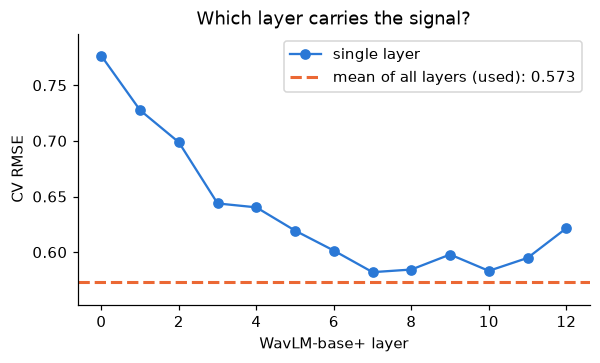

In [7]:
# Per-layer check uses the base model's saved per-layer embeddings: [clips, 13 layers, 768]
A = np.load("kaggle_out/audio/audio_emb.npz")
layers = np.stack([A["train_" + f[:-4]] for f in train.filename])

def cv_rmse(X):
    """5-fold out-of-fold RMSE of the Ridge model on features X (predictions clipped to the 0-5 range)."""
    return rmse(y, np.clip(cross_val_predict(T.model(), X, y, cv=CV), 0, 5))

layer_rmse = [cv_rmse(layers[:, l]) for l in range(layers.shape[1])]
mean_rmse = cv_rmse(layers.mean(1))
plt.figure(figsize=(6, 3.2)); plt.plot(layer_rmse, "o-", color=BLUE, label="single layer")
plt.axhline(mean_rmse, ls="--", lw=2, color=ORANGE, label=f"mean of all layers (used): {mean_rmse:.3f}")
plt.ylim(min(layer_rmse + [mean_rmse]) - 0.02, max(layer_rmse) + 0.02)     # keep the dashed line clear of the axis
plt.xlabel("WavLM-base+ layer"); plt.ylabel("CV RMSE"); plt.title("Which layer carries the signal?"); plt.legend(); plt.show()

The middle-to-upper layers work best. From what I've read, those layers capture speech sounds and words
rather than raw acoustics. Averaging all layers works at least as well as the best single layer (the dashed line is below every point), so I used the average.
That way I'm not choosing a layer based on my validation results.

To see what WavLM "hears", I squashed the embeddings down to 2 dimensions with PCA and coloured each clip by its score:

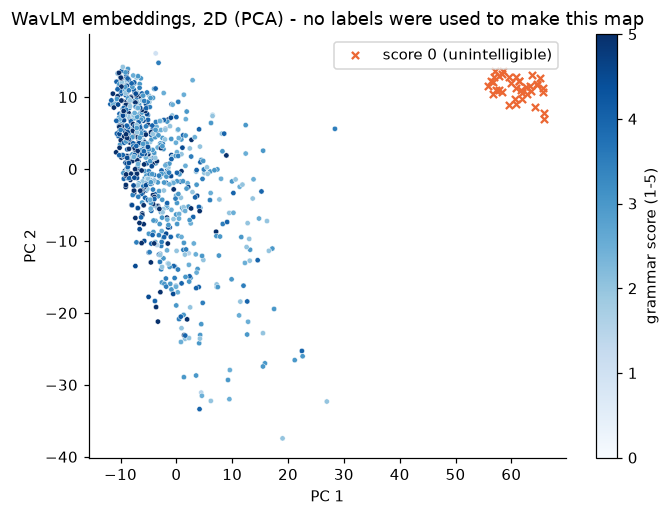

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
Au_vis = F.audio(train, "train", AUDIO_NPZ)
xy = PCA(2, random_state=0).fit_transform(StandardScaler().fit_transform(Au_vis))
plt.figure(figsize=(7, 5))
sc = plt.scatter(xy[~is0, 0], xy[~is0, 1], c=y[~is0], cmap="Blues", vmin=0, s=12, edgecolors="white", linewidths=0.3)
plt.scatter(xy[is0, 0], xy[is0, 1], c=ORANGE, s=22, marker="x", label="score 0 (unintelligible)")
plt.colorbar(sc, label="grammar score (1-5)"); plt.legend(loc="upper right")
plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.title("WavLM embeddings, 2D (PCA) - no labels were used to make this map"); plt.show()

Even without using any labels, the map is roughly ordered by score from top (better speakers, darker) to bottom,
and the score-0 clips form a completely separate cluster on the far right. That's a strong sign that the audio really
carries this information, and it's why the audio model can recognise unintelligible speech (section 6).

I also tried **WavLM-large** (a bigger version, `kaggle_audio_large/`). With my final audio model it wasn't better on its own
(CV RMSE 0.538 vs 0.536) and was worse inside the final ensemble (0.508 vs 0.496), so I kept the smaller, faster base model.
Bigger isn't automatically better with only 769 labelled clips.

## 5. Fine-tuning DeBERTa on the transcripts
Using a frozen sentence embedding with Ridge didn't get me far on the text side. So I fine-tuned **DeBERTa-v3**
to predict the score directly from the transcript (`kaggle_deberta*/`).

Setup: MSE loss with scores scaled to 0–1, AdamW optimiser, cosine learning-rate schedule with warm-up, 6 epochs, max 256 tokens.
I trained for a **fixed number of epochs** instead of picking the best epoch on the validation fold. Picking the best epoch would
make my cross-validation scores look better than they really are. DeBERTa's 5 folds are split over the 732 clips it trains on.

DeBERTa is trained on the 1–5 clips only: the transcripts of score-0 clips are mostly gibberish, and the audio model handles them (section 6).

I tried three versions:

In [9]:
# Out-of-fold predictions from the Kaggle runs (only for the 732 clips scored 1-5)
def load_oof(path):
    return train.filename.map(pd.read_csv(path).set_index("filename").iloc[:, -1]).to_numpy()

base1 = load_oof("kaggle_out/deberta/oof_deberta.csv")                      # base model, seed 42
base3 = (base1 + 2 * load_oof("kaggle_out/deberta_seeds/oof_deberta_s4344.csv")) / 3   # + 2 more seeds, averaged
large = load_oof(TEXT_OOF)                                                    # large model (3x the parameters)
pd.DataFrame({name: {"CV RMSE": rmse(y[~is0], p[~is0]), "CV Pearson": pear(y[~is0], p[~is0])}
              for name, p in [("DeBERTa-v3-base, 1 run", base1), ("DeBERTa-v3-base, 3 runs averaged", base3),
                              ("DeBERTa-v3-large, 1 run", large)]}).T.round(4)

,CV RMSE,CV Pearson
"DeBERTa-v3-base, 1 run",0.6337,0.8068
"DeBERTa-v3-base, 3 runs averaged",0.6294,0.8101
"DeBERTa-v3-large, 1 run",0.5994,0.8149


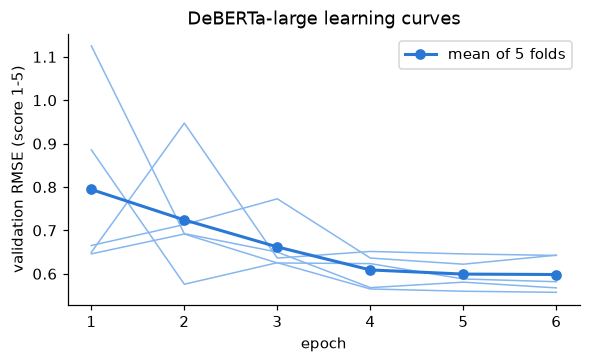

In [10]:
# Validation RMSE after every epoch, per fold, parsed from the Kaggle training log of DeBERTa-large
import re
log = json.loads(Path("kaggle_out/deberta_large/shl-grammar-deberta-large.log").read_text())
curve = pd.DataFrame([map(float, m.groups()) for e in log
                      if (m := re.search(r"fold (\d+) epoch (\d+) val rmse ([\d.]+)", e.get("data", "")))],
                     columns=["fold", "epoch", "val_rmse"])
plt.figure(figsize=(6, 3.2))
for f, g in curve.groupby("fold"): plt.plot(g.epoch + 1, g.val_rmse, color="#86b6ef", lw=1)
m = curve.groupby("epoch").val_rmse.mean(); plt.plot(m.index + 1, m.values, "o-", color=BLUE, lw=2, label="mean of 5 folds")
plt.xlabel("epoch"); plt.ylabel("validation RMSE (score 1-5)"); plt.title("DeBERTa-large learning curves"); plt.legend(); plt.show()

Averaging 3 runs of the base model barely helped, but the **large** model was clearly better, so I use it.
The large model needed a smaller learning rate (1e-5 instead of 2e-5); with big models, too high a learning rate can wipe out what they learned in pre-training.
The learning curves (thin lines = individual folds) flatten out by the last epochs without going back up, so 6 fixed epochs is a reasonable choice.

## 6. Comparing everything, handling score 0, and combining the models
Every number here is 5-fold cross-validation on the training data, so each clip is predicted by a model that never saw it.

A detail worth being precise about: the audio model's folds split all 769 clips, while DeBERTa's folds (on Kaggle) split the
732 clips it trains on, so the two models' folds aren't identical. The combined score is still an honest estimate: for every
clip, *both* predictions come from models that never saw it, and I combine them with a **fixed** rule (the cutoff of 1 and a
50/50 average), with nothing learned from these predictions. Matching folds would only matter if I fitted the blend weights on them.

In [11]:
Au = F.audio(train, "train", AUDIO_NPZ)          # WavLM embedding per clip
E = F.embed(train.text)                          # frozen sentence embedding (only for the comparison)
Hn = H.to_numpy(); base_cols = [c for c in H.columns if not c.startswith("gec_")]
oof = lambda X: np.clip(cross_val_predict(T.model(), X, y, cv=CV), 0, 5)

rows = {}
for name, X in [("hand-made features (no grammar correction)", H[base_cols].to_numpy()), ("hand-made features", Hn),
                ("frozen text embedding", E), ("hand-made + text embedding", np.hstack([Hn, E])),
                ("WavLM audio", Au), ("WavLM audio + hand-made  (Ridge)", np.hstack([Au, Hn]))]:
    rows[name] = oof(X)                          # all of these use the linear Ridge baseline

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

All of the rows above use **Ridge**, a linear model: the score is a weighted sum of the features. That can't capture curved
relationships, like "more words help, but only up to a point". So for the final audio model I tried an **SVR with an RBF kernel**,
which can.

An SVR has two settings to choose: `C` (how closely it fits the training data) and `epsilon` (how big an error it ignores).
To avoid picking them by looking at my own validation scores, I used **nested cross-validation**: inside each of the 5 training folds,
a separate 5-fold search picks the settings, and only then is the held-out fold predicted.

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

X_audio = np.hstack([Au, Hn])
p_nested, chosen = np.zeros(len(y)), []
for tr_idx, va_idx in CV.split(X_audio):                    # outer folds: only used for evaluation
    search = GridSearchCV(make_pipeline(StandardScaler(), SVR()),
                          {"svr__C": [1, 3, 10, 30], "svr__epsilon": [0.05, 0.1, 0.2]},
                          cv=KFold(5, shuffle=True, random_state=1), scoring="neg_root_mean_squared_error")
    search.fit(X_audio[tr_idx], y[tr_idx])                  # inner folds: choose C and epsilon on training data only
    p_nested[va_idx] = np.clip(search.predict(X_audio[va_idx]), 0, 5)
    chosen.append(tuple(search.best_params_.values()))
print("settings chosen in each outer fold (C, epsilon):", chosen)

# Every fold chose the same settings, so this model fixes them (train.clip_svr = SVR(C=3, epsilon=0.05))
p_svr = np.clip(cross_val_predict(T.clip_svr(), X_audio, y, cv=CV), 0, 5)
rows["WavLM audio + hand-made  (SVR, one row per clip; v6)"] = p_svr
print(f"nested-CV RMSE {rmse(y, p_nested):.4f}  |  fixed-settings RMSE {rmse(y, p_svr):.4f}")

# Tree models are a common choice for tabular features, so I compared them on the same inputs
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
gbm = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_leaf_nodes=15, l2_regularization=1.0, random_state=0)
rows["WavLM audio + hand-made  (gradient boosting)"] = np.clip(cross_val_predict(gbm, X_audio, y, cv=CV), 0, 5)
rows["WavLM audio + hand-made  (random forest)"] = np.clip(cross_val_predict(
    RandomForestRegressor(500, min_samples_leaf=3, n_jobs=-1, random_state=0), X_audio, y, cv=CV), 0, 5)

settings chosen in each outer fold (C, epsilon): [(3, 0.05), (3, 0.05), (3, 0.05), (3, 0.05), (3, 0.05)]
nested-CV RMSE 0.5359  |  fixed-settings RMSE 0.5359


Every outer fold independently picked the same settings, and the nested score matches, so the SVR's gain over Ridge
(0.563 → 0.536) isn't the result of a lucky choice.

I also tried tree models (gradient boosting and random forest), which are popular for this kind of feature table. They did worse
(see the table below). Trees split on one feature at a time, which works well for a handful of hand-made features but poorly for a
768-number embedding, where the information is spread across many dimensions. SVR uses all of them together.

### More training rows: scoring pieces of each clip (v9, v10)
Every model so far learns from just **769 rows**, one per clip, which is the real limit on this data. So I cut each clip into
**overlapping 10-second pieces, one starting every 5 seconds** (`transcribe.split_pieces`), embedded each piece separately with
WavLM (`kaggle_audio_pieces_variants/`), and gave every piece its clip's score. That turns 769 rows into about **7,700**. Each
piece's row is [piece embedding, whole-clip embedding, the clip's hand-made features], and a clip's audio score is the
**median** of its pieces' predictions, so one odd piece can't pull it far.

Two details matter for honest numbers:
- **Folds are split by clip.** Pieces of one clip are never in both training and validation; otherwise the model would be
  tested on a speaker it had already heard.
- **The SVR's settings were re-chosen by nested CV** (with clip-grouped inner folds too). With ~5–10× more rows it picked a
  more regularised `C=1` in most folds (`train.audio_model`).

I first tried non-overlapping 10 s pieces averaged together (v9), then compared 5 s, 15 s and overlapping pieces, each with
mean or median, across 5 different fold splits. Overlapping 10 s pieces with the median were best on every split (section 10).

In [13]:
# The final audio model: overlapping 10 s pieces, SVR(C=1, epsilon=0.05), clip score = median over pieces.
# train.pieces_cv splits folds by clip, using the same CV object as everything else.
Pc = F.audio_pieces(train, "train")
print(f"{sum(map(len, Pc))} pieces from {len(Pc)} clips ({min(map(len, Pc))}-{max(map(len, Pc))} per clip)")
p_audio = T.pieces_cv(Pc, Au, Hn, y, CV)
rows["pieces of each clip (SVR)  [audio model, v10]"] = p_audio
print(f"audio model CV RMSE: one row per clip {rmse(y, p_svr):.4f}  ->  pieces {rmse(y, p_audio):.4f}")

7725 pieces from 769 clips (3-11 per clip)
audio model CV RMSE: one row per clip 0.5359  ->  pieces 0.5185


Next: can the audio model also spot the unintelligible clips?

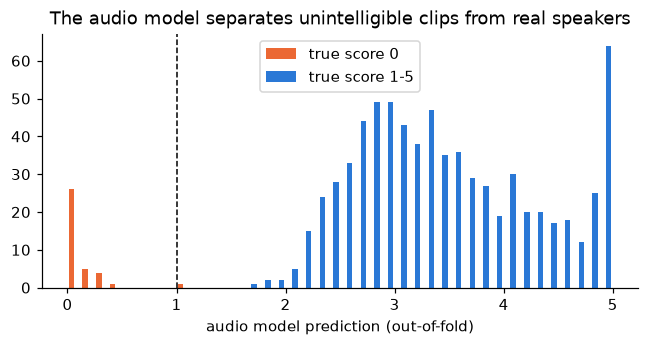

score-0 clips predicted < 1: 36/37   real speakers predicted < 1: 0/732


In [14]:
# Gate: does the audio model separate the score-0 clips from real speakers?
plt.figure(figsize=(7, 3))
plt.hist([p_audio[is0], p_audio[~is0]], bins=40, label=["true score 0", "true score 1-5"], color=[ORANGE, BLUE])
plt.axvline(1, c="k", ls="--", lw=1); plt.legend(); plt.xlabel("audio model prediction (out-of-fold)")
plt.title("The audio model separates unintelligible clips from real speakers"); plt.show()
print(f"score-0 clips predicted < 1: {(p_audio[is0] < 1).sum()}/{is0.sum()}   real speakers predicted < 1: {(p_audio[~is0] < 1).sum()}/{(~is0).sum()}")

This is why I kept the score-0 clips. The audio model puts **36 of the 37** score-0 clips below 1, and **every** real
speaker above 1 (the lowest real speaker gets about 1.7). The one it misses scores 1.1, just above the cutoff.
I kept the cutoff at 1, the rubric's minimum, instead of moving it into that tiny gap, which would be tuning it to
this exact data. The cost of that one miss is already included in all the numbers below. So my rule is simple:

- if the audio model predicts **below 1** (under the rubric's minimum), the speech is unintelligible: use the audio model's score (close to 0);
- otherwise, average the audio model and the DeBERTa text model 50/50.

I didn't tune the 50/50 weight, to keep things simple and avoid an over-optimistic score. The curve below shows how close 0.5 is to the best weight.

In [15]:
# The final rule lives in one place, train.combine_scores, which predict.py also uses (and test_pipeline.py checks):
# audio score < 1 -> keep it (unintelligible); otherwise w * audio + (1 - w) * text, with w = 0.5
ensemble = T.combine_scores

rows["fine-tuned DeBERTa-v3-large  [text model, 1-5 clips only]"] = large
p_ens = ensemble(p_audio, large); rows["**FINAL: gate + 0.5 audio + 0.5 text**"] = p_ens

# Table: RMSE on all clips, on the 1-5 clips, and Pearson (the text model has no score-0 predictions, so it gets NaN for "all")
def summary(p):
    ok = ~np.isnan(p)
    return {"CV RMSE (all clips)": rmse(y, p) if ok.all() else np.nan, "CV RMSE (score 1-5)": rmse(y[~is0], p[~is0]),
            "CV Pearson (all)": pear(y[ok], p[ok])}
table = pd.DataFrame({k: summary(v) for k, v in rows.items()}).T.round(4)
table

,CV RMSE (all clips),CV RMSE (score 1-5),CV Pearson (all)
hand-made features (no grammar correction),0.9907,0.8884,0.6006
hand-made features,0.9657,0.8535,0.6271
frozen text embedding,1.0127,0.8338,0.5756
hand-made + text embedding,0.9373,0.7935,0.6537
WavLM audio,0.5728,0.5863,0.8867
WavLM audio + hand-made (Ridge),0.5634,0.5759,0.8907
"WavLM audio + hand-made (SVR, one row per clip; v6)",0.5359,0.5432,0.9025
WavLM audio + hand-made (gradient boosting),0.5856,0.5996,0.8818
WavLM audio + hand-made (random forest),0.6307,0.6461,0.8652
"pieces of each clip (SVR) [audio model, v10]",0.5185,0.5289,0.9088


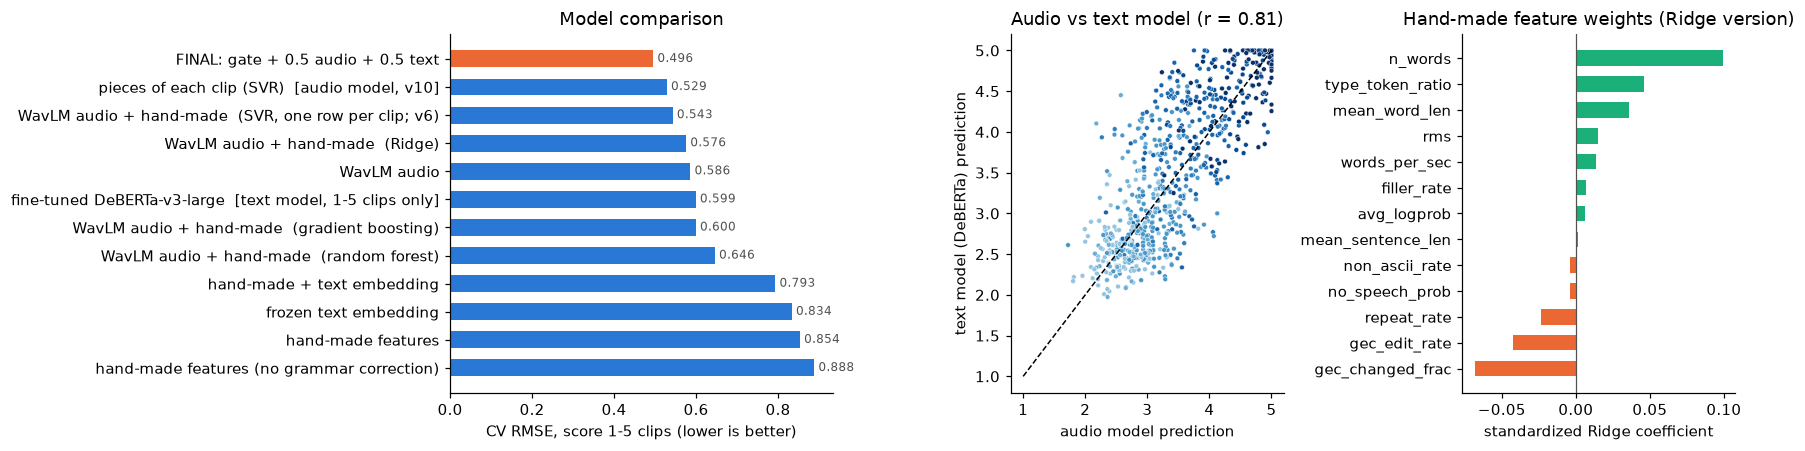

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2), gridspec_kw={"width_ratios": [1.4, 1, 1]})
# (a) every model's CV RMSE on the 1-5 clips (the only set all models can be compared on)
t = table["CV RMSE (score 1-5)"].sort_values(ascending=False)
ax[0].barh([k.replace("*", "") for k in t.index], t.values, color=[ORANGE if "FINAL" in k else BLUE for k in t.index], height=0.6)
for i, v in enumerate(t.values): ax[0].text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8, color=INK)
ax[0].set_xlabel("CV RMSE, score 1-5 clips (lower is better)"); ax[0].set_title("Model comparison")
# (b) the two models disagree -> averaging helps
ok = ~is0
ax[1].scatter(p_audio[ok], large[ok], c=y[ok], cmap="Blues", vmin=0, s=10, edgecolors="white", linewidths=0.3)
ax[1].plot([1, 5], [1, 5], "k--", lw=1); ax[1].set_xlabel("audio model prediction"); ax[1].set_ylabel("text model (DeBERTa) prediction")
ax[1].set_title(f"Audio vs text model (r = {np.corrcoef(p_audio[ok], large[ok])[0, 1]:.2f})")
# (c) which hand-made features matter: standardized coefficients of the Ridge version (an RBF SVR has no per-feature weights)
full = T.model().fit(np.hstack([Au, Hn]), y)
coef = pd.Series(full[-1].coef_[-Hn.shape[1]:], index=H.columns).sort_values()
ax[2].barh(coef.index, coef.values, color=np.where(coef > 0, AQUA, ORANGE), height=0.6); ax[2].axvline(0, c=INK, lw=0.8)
ax[2].set_title("Hand-made feature weights (Ridge version)"); ax[2].set_xlabel("standardized Ridge coefficient")
plt.tight_layout(); plt.show()

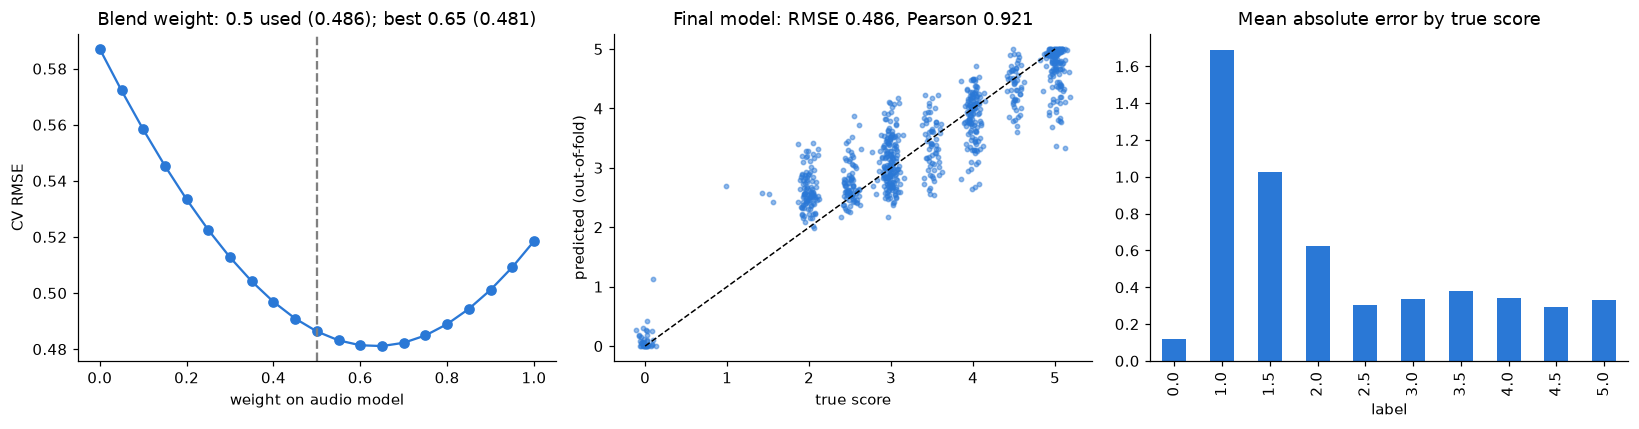

In [17]:
ws = np.linspace(0, 1, 21)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(ws, [rmse(y, ensemble(p_audio, large, w)) for w in ws], "o-", color=BLUE); ax[0].axvline(0.5, ls="--", c="gray")
curve_w = [rmse(y, ensemble(p_audio, large, w)) for w in ws]
ax[0].set_xlabel("weight on audio model"); ax[0].set_ylabel("CV RMSE")
ax[0].set_title(f"Blend weight: 0.5 used ({rmse(y, p_ens):.3f}); best {ws[np.argmin(curve_w)]:.2f} ({min(curve_w):.3f})")
jit = np.random.default_rng(0).normal(0, .06, len(y))           # small jitter so overlapping points are visible
ax[1].scatter(y + jit, p_ens, s=8, alpha=.5, color=BLUE); ax[1].plot([0, 5], [0, 5], "k--", lw=1)
ax[1].set_xlabel("true score"); ax[1].set_ylabel("predicted (out-of-fold)")
ax[1].set_title(f"Final model: RMSE {rmse(y, p_ens):.3f}, Pearson {pear(y, p_ens):.3f}")
pd.DataFrame({"label": y, "abs_err": np.abs(p_ens - y)}).groupby("label").abs_err.mean().plot.bar(ax=ax[2], color=BLUE)
ax[2].set_title("Mean absolute error by true score"); plt.tight_layout(); plt.show()

**What I take from this:**
- The audio model is the strongest single model. The grammar-correction features clearly help compared to just fluency features.
- The text and audio models only partly agree (middle plot), which means they make different mistakes. That's why averaging them helps.
- In the Ridge version of the audio model, the biggest hand-made weights go to the number of words (positive) and the two grammar-correction
  features (negative: more corrections → lower score), which matches section 3. (Weights are on standardized features, so they're comparable; correlated
  features share weight, so I read them as a rough guide rather than exact importance.)
- The model is least accurate for scores 1–2 and 5. There are few low-score examples to learn from, and models trained with MSE
  tend to predict towards the middle.

## 7. Training RMSE (required) and final test predictions

Audio model, fitted on all training data -> training RMSE (in-sample): 0.0598
Final model, training data, 5-fold out-of-fold RMSE:               0.4863   (Pearson 0.9213)
test clips flagged as unintelligible (audio < 1): 0


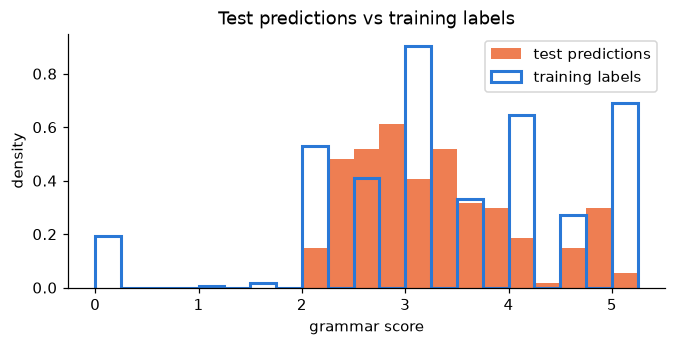

,count,mean,std,min,25%,50%,75%,max
label,216.0,3.289568,0.779652,2.029666,2.692081,3.197148,3.721441,5.0


In [18]:
# Audio model refitted on ALL training clips' pieces (this is also what train.py saves to models/audio_model.joblib)
every = np.arange(len(y))
audio_model = T.fit_pieces(Pc, Au, Hn, y, every)        # SVR(C=1, epsilon=0.05) on ~7,700 piece rows
print(f"Audio model, fitted on all training data -> training RMSE (in-sample): {rmse(y, T.predict_pieces(audio_model, Pc, Au, Hn, every)):.4f}")
print(f"Final model, training data, 5-fold out-of-fold RMSE:               {rmse(y, p_ens):.4f}   (Pearson {pear(y, p_ens):.4f})")

# Test: audio model + DeBERTa-large test predictions (averaged over its 5 fold models on Kaggle), same gate
Pt, At, Ht = F.audio_pieces(test, "test"), F.audio(test, "test", AUDIO_NPZ), F.handcrafted(test, "test").to_numpy()
audio_test = T.predict_pieces(audio_model, Pt, At, Ht, np.arange(len(test)))
text_test = test.filename.map(pd.read_csv(TEXT_TEST).set_index("filename").iloc[:, -1]).to_numpy()
pred = np.clip(ensemble(audio_test, text_test), 0, 5)
print("test clips flagged as unintelligible (audio < 1):", int((audio_test < 1).sum()))

sub = pd.DataFrame({"filename": test.filename, "label": pred})
assert len(sub) == 216 and set(sub.filename) == set(pd.read_csv("data/Dataset_Final/test.csv").filename) and sub.label.between(0, 5).all()
sub.to_csv("submission.csv", index=False)

plt.figure(figsize=(7, 3))
bins = np.arange(0, 5.26, 0.25)
plt.hist(pred, bins=bins, density=True, color=ORANGE, alpha=0.85, label="test predictions")
plt.hist(y, bins=bins, density=True, histtype="step", lw=2, color=BLUE, label="training labels")
plt.xlabel("grammar score"); plt.ylabel("density"); plt.legend(); plt.title("Test predictions vs training labels"); plt.show()
sub.describe().T

The out-of-fold RMSE is the honest number, because each training clip is predicted by models that never saw it.
The in-sample RMSE is much lower. That's typical for an SVR: it can bend to fit the training points closely (and here every
training clip is seen as several overlapping pieces), so its error on data it has already seen says little about new data.
That's exactly why I judge everything by cross-validation. I also checked whether that gap was hurting accuracy (section 10):
stronger regularization shrinks it, but the cross-validated error doesn't change.
The test predictions are bunched closer to the middle than the true labels. That's expected for a model trained to minimise
squared error: when unsure, predicting near the average is the safest guess. No test clip was flagged as unintelligible.

## 8. Audio file in → score out: `predict.py`
The task asks for a model that takes an **audio file** and outputs a score. `predict.py` does exactly that, end to end:
Whisper → grammar correction → WavLM (whole clip and each 10 s piece) → audio model → gate → DeBERTa → final score. It reuses
the same feature code and the same piece-cutting rule as training, and I checked that it reproduces the training features and
piece embeddings exactly on sample clips.

```bash
python predict.py path/to/clip.wav
```
It needs `models/audio_model.joblib` (from `train.py`) and `models/deberta_final/` (DeBERTa-large trained on all clips, `kaggle_deberta_final/`).
Here it is on three training clips with different true scores:

In [19]:
import predict
import huggingface_hub.utils, transformers
huggingface_hub.utils.disable_progress_bars(); transformers.logging.disable_progress_bar()   # keep the output readable
if (Path("models") / "deberta_final").exists():
    for f in [train[train.label == 0].filename.iloc[0], train[train.label == 2].filename.iloc[0], train[train.label == 5].filename.iloc[0]]:
        s = predict.score(f"data/Dataset_Final/train/{f}")
        print(f"{f}: predicted {s:.2f}   (true score {train.set_index('filename').label[f]})")
else:
    print("models/deberta_final/ not found - see README to create it")

audio_5055.wav: predicted 0.00   (true score 0.0)
audio_126.wav: predicted 2.08   (true score 2.0)
audio_592.wav: predicted 4.93   (true score 5.0)


(These clips were part of training, so they're only a check that the pipeline works end to end, not an accuracy estimate.
The score-0 clip can come out slightly differently between runs (I've seen 0.00–0.18): on garbled speech Whisper falls back to
sampling, so its transcript varies a little. For normal speech the outputs were identical in every run I checked, and the
score-0 clip always stays far below the cutoff of 1, so the decision never changes.

One difference between `predict.py` and `submission.csv`: for the submission, DeBERTa's test score is the average of the 5
cross-validation models; `predict.py` uses one DeBERTa-large retrained on all 732 clips (`kaggle_deberta_final/`), which is the
usual way to ship a model. I checked they agree: on the 216 test clips the two DeBERTa versions correlate at 0.987, and the final
scores differ from the submitted ones by 0.06 on average (at most 0.22).
The cross-validation numbers above are the accuracy estimate.)

## 9. How my score improved

| # | what I changed | CV RMSE | public RMSE |
|--|--|--|--|
| 1 | transcript features + frozen text embedding, Ridge | 0.943 | 0.658 |
| 2 | dropped the score-0 clips; added grammar-correction features | 0.743* | 0.568 |
| 3 | added WavLM audio embeddings | 0.571* | 0.439 |
| 4 | averaged with fine-tuned DeBERTa-base | 0.531* | 0.3625 |
| 5 | kept score-0 clips with the "audio < 1" gate (full 0–5 output); DeBERTa-large | 0.523* (0.512 on all clips) | 0.3663 |
| 6 | audio model Ridge → SVR (settings chosen by nested CV) | 0.502* (0.496 on all clips) | **0.3510** |
| 7 | *experiment, not adopted:* text model averaged over 3 DeBERTa-large runs | 0.501* (0.495 on all clips) | 0.3522 |
| 8 | *experiment, not adopted:* learned blend 0.667 × audio + 0.420 × text − 0.332 | 0.494* (0.488 on all clips) | 0.3566 |
| 9 | audio model trained on 10 s **pieces** of each clip (mean over pieces) | 0.499* (0.490 on all clips) | 0.3477 |
| 10 | **overlapping** 10 s pieces, median over pieces (**final**) | 0.496* (0.486 on all clips) | **0.3466** |
| 11a | *experiment, not adopted:* audio model also trained on 0.9× / 1.1× speed copies of each clip | (0.480 on all clips, avg of 5 splits) | 0.3471 |
| 11c | *experiment, not adopted:* v10 with the blend weight 0.65 audio / 0.35 text | (0.4765 on all clips, avg of 5 splits) | 0.3604 |

\* measured on the 1–5 clips only, while I was leaving the score-0 clips out.

For steps 1–4, my cross-validation score and leaderboard score improved together, which made me trust my local evaluation.
Step 5 is the interesting one: CV improved (0.531 → 0.523) but the public score got slightly worse (0.3625 → 0.3663).
The public leaderboard is computed on at most 216 clips, while CV uses 769, so a 0.004 difference there is well within noise.
I kept version 5 anyway: it's better by the more reliable measure, it outputs the full 0–5 range the task asks for, and it's
the same model `predict.py` ships. Changing the model to chase the public number would just be overfitting to those clips.
Version 6 (the SVR) then improved both: CV 0.523 → 0.502 and public 0.3663 → 0.3510, my best score at that point. Version 7 (section 10)
improved CV by only 0.0016 and scored 0.3522 publicly, a noise-sized difference in the other direction, so v6 stayed final.
Version 8 (a learned blend, section 10) had a real CV gain, but it scored 0.3566 publicly, so v6 stayed final again.
Version 9 was the first idea after v6 to improve **both**: training the audio model on 10 s pieces of each clip (CV 0.502 →
0.499, public 0.3510 → 0.3477). Version 10 refined it with overlapping pieces and the median (public 0.3466), and is the final
model. Its gain over v9 is small, but CV and the public score agreed, which was the rule I used for every change.
Versions 11a and 11c (section 10) both improved CV but not the public score, so v10 stayed final.

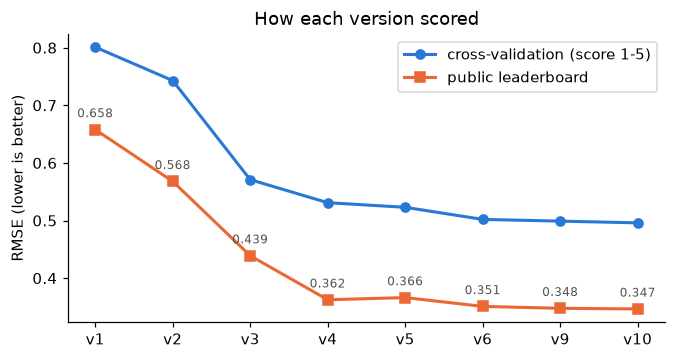

In [20]:
# CV vs public leaderboard RMSE for each submission (CV on the 1-5 clips, so all versions are comparable)
hist = pd.DataFrame({"version": ["v1", "v2", "v3", "v4", "v5", "v6", "v9", "v10"],  # adopted versions only
                     "CV RMSE (score 1-5)": [0.801, 0.743, 0.571, 0.531, 0.523, 0.502, 0.499, 0.496],
                     "public leaderboard RMSE": [0.658, 0.568, 0.439, 0.3625, 0.3663, 0.3510, 0.3477, 0.3466]})
plt.figure(figsize=(7, 3.4))
plt.plot(hist.version, hist["CV RMSE (score 1-5)"], "o-", color=BLUE, lw=2, label="cross-validation (score 1-5)")
plt.plot(hist.version, hist["public leaderboard RMSE"], "s-", color=ORANGE, lw=2, label="public leaderboard")
for i, r in hist.iterrows():
    plt.annotate(f'{r["public leaderboard RMSE"]:.3f}', (i, r["public leaderboard RMSE"]), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8, color=INK)
plt.ylabel("RMSE (lower is better)"); plt.title("How each version scored"); plt.legend(); plt.show()

(v1's CV here is measured on the 1–5 clips, 0.801, so it's comparable with the later versions; the 0.943 in the table included the score-0 clips.)

## 10. What I tried after v6
After v6 I tried many more ideas on Kaggle. My rule was to keep a change only if CV improved clearly and, when I submitted
it, the public score agreed, because small differences are below the noise of a 216-clip leaderboard. One idea made it into
the final model (scoring pieces of each clip, v9 → v10); the rest didn't.

| experiment | CV RMSE (all clips) | result |
|---|---|---|
| v6 | 0.4963 | – |
| **Fine-tuning WavLM** end to end (`kaggle_wavlm_finetune/`): learned layer mix, frozen CNN encoder, random 15 s crops, 10 fixed epochs | 0.666 on its own (vs 0.536 for frozen WavLM + SVR) | worse |
| ...added to the audio model with a weight chosen by nested CV | 0.4947 | nested CV gave it **zero** weight |
| **3 DeBERTa-large runs** averaged instead of 1 (`kaggle_deberta_large_seeds/`) | 0.4947 | tiny gain; submitted as v7: public 0.3522 vs v6's 0.3510 |
| **Better transcripts:** Whisper large-v3 (full model) instead of turbo (`kaggle_asr_v3/`, `kaggle_deberta_large_v3/`), best combination | 0.4968 | no gain; using large-v3 for both models: 0.5077 |
| **"What Whisper corrected":** disagreement between Whisper and a speech model without a language model - wav2vec2 (`kaggle_ctc_disagreement/`) | 0.4960 | no gain |
| ...same with NVIDIA Parakeet, TDT and CTC models (`kaggle_parakeet/`), best of 6 combinations | 0.4956 | no gain |
| **Grammatical complexity** (spaCy parse: subordinate clauses, tree depth, verb-form variety...) and **error types** (missing / extra / wrong words) (`kaggle_features_v2/`) | 0.4969–0.4979 | slightly worse |
| **LLM grammar judge:** Qwen2.5-7B-Instruct rates each transcript 1–5 against SHL's rubric, zero-shot (`kaggle_llm_judge/`) | 0.4961 as a feature | no gain; as a third model, nested CV gave it **zero** weight in all 5 folds |
| **Whisper's encoder** as a second audio embedding next to WavLM (`kaggle_whisper_encoder/`) | 0.5155 | worse; it also catches fewer score-0 clips (32/37 vs 36/37) |
| **Learned blend (stacking):** non-negative linear regression on the audio and text predictions, fitted with nested CV | **0.4884** (5 different splits: 0.4882–0.4896) | real CV gain; submitted as v8: public **0.3566** vs v6's 0.3510, so not adopted |
| **Stronger regularization of the audio model** to shrink its train/CV gap: tuning the RBF `gamma`, and PCA on the WavLM block inside the pipeline (`kaggle_regularization/`), all nested | 0.4950 / 0.5070 | no gain; CV error unchanged (0.5362 / 0.5354) |
| **Scores as ordered categories:** one logistic model per score step ("is it at least 3?"), expected value; C by nested CV | 0.5036 alone; 0.4943 averaged with the SVR | no real gain: the small improvement came only from score-0 clips (none in the test set); on scores 1–5 it was worse |
| **Scoring pieces of each clip** (non-overlapping 10 s, mean over pieces; `kaggle_audio_pieces/`) | 0.4898 (avg of 5 splits: 0.4856) | **adopted as v9**: public 0.3477 vs v6's 0.3510 |
| ...piece length 5 s / 15 s, overlapping 10 s pieces every 5 s, mean or median (`kaggle_audio_pieces_variants/`), compared over 5 splits | best: overlapping + median, avg of 5 splits 0.4822 (vs 0.4856), better on every split | **adopted as v10**: public 0.3466 |
| **DeBERTa on ~15 s transcript windows** (one every 7.5 s, cut with Whisper's timestamps; median over windows; `kaggle_deberta_windows/`) | 0.616 on its own (vs 0.599 for whole transcripts); ensemble 0.4960 avg of 5 splits (vs 0.4822); averaged with the whole-transcript DeBERTa 0.4827 | worse |
| **Speed augmentation:** 0.9× and 1.1× speed copies of every training clip, cut into the same pieces (`kaggle_audio_augment/`); evaluation always on the original audio | 0.4800 avg of 5 splits (vs 0.4822), better on every split | small gain; submitted as v11a: public 0.3471 vs v10's 0.3466, so not adopted |
| **Blend weight re-checked** after v10 (weight chosen on 4 folds, scored on the 5th; it always picked 0.6–0.7 for audio) | 0.4765 avg of 5 splits with weight 0.65 (vs 0.4822) | submitted as v11c: public **0.3604**, so not adopted |

Fine-tuning WavLM overfit: in three folds (one only marginally) the score at epoch 5 was better than at epoch 10, one fold was unstable (0.835),
the learned layer weights barely moved from equal, and its predictions correlate 0.92 with the frozen model's, so it adds
little new. With 769 clips there isn't enough data to fine-tune a 95M-parameter speech model reliably, which is why the frozen
encoder + SVR is the better choice here. (A detail I learned on the way: WavLM-base-plus ships with LayerDrop, which randomly
skips layers during training, so a learned mix over all layers needs it switched off.)

A later code review found a bug in that run: when scoring a clip, its shorter last 15 s piece was zero-padded in a batch
with the full pieces, and the model averaged the padding into its prediction. It affected 100 of the 769 training clips.
The conclusion doesn't change: on the 669 clips it never touched, the fine-tuned model scores 0.671 against 0.524 for the
frozen one, an even bigger gap. The script is fixed (each piece is now scored on its own) but I didn't re-run it.

The extra DeBERTa runs helped the text model alone (0.599 → 0.590) but barely moved the ensemble: the runs agree closely
(correlation 0.97), and the audio model already covers most of what they get wrong. Not worth the extra complexity.

The large-v3 transcripts looked better at first: more of them kept "uh/um" (43% vs 39%), the grammar-correction edit rate
tracked the scores more closely (Spearman −0.543 vs −0.517), and the hand-made features alone improved a lot (CV RMSE
0.966 → 0.861). But it didn't carry through. The audio model barely moved (0.5359 → 0.5345), because WavLM already hears
most of what the cleaner transcripts add. DeBERTa got worse on them (0.617 vs 0.599), perhaps because the extra fillers and
false starts make the text less like the written English it was pre-trained on. And the two DeBERTa versions agree too
closely (correlation 0.965) for averaging them to help. So the turbo transcripts stayed.

**Strong features can still be useless.** The newer features weren't weak. Measured on the clips scored 1–5:

| feature | Spearman with score |
|---|---|
| grammar-correction edit rate (already in the model) | −0.517 |
| disagreement between Whisper and Parakeet-CTC | −0.482 |
| disagreement between Whisper and Parakeet-TDT | −0.467 |
| disagreement between Whisper and wav2vec2 | −0.414 |
| wrong-word rate (one of the error types) | −0.402 |
| verb-form variety (the best complexity feature) | +0.181 |
| **LLM rubric rating** (expected value of its 1–5 answer) | **+0.602** |

The disagreement and error-type features track the score about as strongly as the grammar-correction rate. But none of them
improved the model, because they measure the **same thing it already knows**: speakers who make more mistakes and are harder
to understand get lower scores, and the grammar-correction rate, WavLM and DeBERTa already capture that. A new feature only
helps if it adds information the model doesn't have, not just if it correlates with the target.

The complexity features, which were meant to reward simple-but-correct speakers less than speakers who use complex grammar
well, turned out to be weak in this data (only verb-form variety reaches +0.18).

The LLM judge is the clearest example. It's the strongest single text feature I found (+0.602, better than the
grammar-correction rate), and on its own it improves the hand-made features a lot (0.966 → 0.885). But its ratings are
squeezed into a narrow range (average 2.85 for clips scored 1, 3.94 for clips scored 5), and what it knows overlaps with
DeBERTa, which reads the same transcripts and was trained on these labels. Next to DeBERTa and WavLM it adds nothing.
I kept it zero-shot on purpose: putting scored training clips in the prompt would leak their labels into cross-validation.

The learned blend is the most interesting result. Its weights (score = 0.667 × audio + 0.420 × text − 0.332) do two
things: they trust the audio model more than 50/50, and because the weights add up to more than 1 and the intercept is
negative, they stretch the predictions outward, undoing the MSE models' habit of crowding scores toward the middle. In
cross-validation that's a stable 0.008 gain. On the public leaderboard it scored worse (0.3566 vs 0.3510). My best
explanation: the test set looks easier and more tightly bunched than the training set (no score-0 clips; every version
scores about 0.35 publicly against about 0.50 in CV), so stretching predictions toward the *training* spread pushes test
predictions too far. With only 216 public clips, part of that gap may also be noise. The lesson I take from it: a gain
that depends on matching the training label distribution won't transfer if the test distribution is different.

**Is the audio model overfitting?** (Tested on v6's one-row-per-clip SVR.) Its training error (0.105) is far below its
cross-validated error (0.536), so I tested
whether reining it in would help. Tuning `gamma` (never tuned before; smaller values force a smoother model) and
compressing the 768 WavLM numbers with PCA (fitted inside each training fold) both shrink the gap, raising training error to
about 0.135. But the cross-validated error doesn't move (0.5362 and 0.5354 vs 0.5359), the folds disagree on the best
`gamma`, and PCA misses one more unintelligible clip. So the gap isn't costing accuracy: an RBF SVR naturally fits its
training points closely, and what matters is error on unseen clips, which was already as low as these settings allow.

**Scoring pieces of each clip worked where the rest didn't, because it attacked the real limit: the amount of training
data.** Every other idea after v6 either measured what the model already knew, overfit 769 clips, or (like the learned blend)
helped in CV but didn't survive a different test distribution. Cutting clips into pieces gives the audio model ~10× more
training rows from the same audio, without new labels. It's an approximation (grammar quality isn't identical in every
10 seconds), which is why the median over pieces works better than the mean. The exact piece length barely matters: 5 s,
10 s and overlapping 10 s pieces were within 0.003 of each other; only 15 s pieces were clearly worse. A bigger improvement
than this would most likely need more labelled audio, especially at scores 1–2.

**The same trick didn't work for the text model.** Cutting transcripts into ~15 s windows gives DeBERTa 7× more rows, but a
15 s window has only about 27 words. Many windows contain no mistake at all and still inherit their clip's score, so the
labels get noisy, and the windows model is worse than the whole-transcript one (0.616 vs 0.599). Audio pieces don't have this
problem as much: how someone sounds (fluency, pronunciation, hesitation) is present in every 10 seconds, while a grammar
mistake is a rare event that a short window can easily miss.

**Speed augmentation** (playing each training clip 10% slower and 10% faster, a standard trick from speech recognition)
improved CV on every one of the 5 splits, but by only 0.002, and the public score was 0.0005 worse, which is noise in either
direction. By my rule it wasn't adopted. It also tripled the SVR's training rows (~23,000), which made it ~6× slower than it
needed to be at first: scikit-learn's SVR caches kernel values in 200 MB by default, and with 18,000 rows per fold it kept
recomputing them. `SVR(cache_size=4000)` brought one fold from ~250 s to 44 s with identical predictions.

**The blend weight was the clearest lesson.** Once the audio model improved, choosing the weight by nested CV moved it to
0.65 for audio in every fold, for a CV gain of 0.006, the largest since v10. On the public leaderboard it scored 0.3604, much
worse than 0.3466. The reason is a mismatch between CV and test: in CV each clip's DeBERTa score comes from **one** model,
but the test score averages **five** fold models, which is more accurate. So CV underrates the text model and pushes weight
towards audio. (v8's learned blend failed the same way.) Equal weights stay, and I didn't tune the weight against the public
leaderboard, because that would just fit those 216 clips.

Two honest notes. My first version of these scripts printed the correlations wrongly (pandas paired the wrong rows after
filtering), and I briefly concluded the features had no signal at all; the RMSE results were never affected, and the
scripts are fixed. And wav2vec2's sample transcripts looked like gibberish because the script printed the clips with the
*most* disagreement, the worst cases, so they aren't representative.

## 11. Limitations and what I'd try next
- **Whisper still cleans up speech.** An ASR model trained to transcribe word-for-word, including mistakes, would keep more of the signal.
- **Not many low-score examples.** More data at scores 1–2 would help most; treating scores as ordered categories didn't (section 10).
- **More data before bigger audio models.** Fine-tuning WavLM overfit on 769 clips (section 10). With more labelled audio, fine-tuning, or one model trained on audio and text together, would be worth revisiting.
- **The "audio < 1" gate** catches 36 of 37 score-0 clips here, but with so few examples I'd want more data before trusting it in production.

## 12. If this had to run in production
Right now one clip goes through four big models (Whisper, CoEdIT, WavLM - once for the clip and once per 10 s piece -
and DeBERTa-large), which takes about a minute on my laptop.
That's fine for a challenge, but too slow and expensive for millions of test-takers. What I'd do:
- **Start with the audio model alone.** Without DeBERTa it already gets CV RMSE ≈ 0.52 (vs 0.49 for everything), and WavLM-base is small.
  The text side could become an optional second pass, only for clips where the score is borderline.
- **Use lighter versions of each model:** a distilled Whisper (e.g. distil-whisper), DeBERTa-base instead of large (about 0.015 worse here),
  and quantised or ONNX-exported models for faster CPU inference.
- **Batch and cache:** process clips in batches on a GPU server, and never re-run a model on audio it has already seen.
- **Monitor it:** track the share of clips flagged as unintelligible and how predictions are distributed over time, because a change in
  microphones or test prompts would show up there first.